In [1]:
import pandas as pd

# ── ADJUST THIS PATH to your actual folder location ──────────────────────────
DATA_PATH = "/Users/ivnyam/Downloads/FoodData_Central_csv_2026-04-30"

# Step 1: Load foods, filter to SR Legacy only (~7,800 well-tested foods)
foods = pd.read_csv(f'{DATA_PATH}/food.csv')
foods_sr = foods[foods['data_type'] == 'sr_legacy_food'].copy()
print(f"SR Legacy foods: {len(foods_sr):,}")

# Step 2: Load food categories
food_cats = pd.read_csv(f'{DATA_PATH}/food_category.csv')

# Step 3: Load nutrient values (27M rows — filter to SR Legacy fdc_ids first)
print("Loading nutrient data (~30 seconds)...")
fdc_ids_sr = set(foods_sr['fdc_id'])
food_nutrients = pd.read_csv(
    f'{DATA_PATH}/food_nutrient.csv',
    usecols=['fdc_id', 'nutrient_id', 'amount']
)
food_nutrients_sr = food_nutrients[food_nutrients['fdc_id'].isin(fdc_ids_sr)].copy()

# Step 4: Keep only the nutrients we care about
# Note: SR Legacy foods use nutrient_id 2000 ("Total Sugars"), not 1063
# ("Sugars, Total") — 1063 has zero coverage in this dataset for SR Legacy foods.
KEY_NUTRIENTS = {
    1008: 'Energy_kcal',
    1003: 'Protein_g',
    1004: 'Fat_g',
    1005: 'Carbs_g',
    1079: 'Fiber_g',
    2000: 'Sugar_g',
    1093: 'Sodium_mg',
    1087: 'Calcium_mg',
    1089: 'Iron_mg',
    1162: 'VitaminC_mg',
    1253: 'Cholesterol_mg',
}
food_nutrients_sr = food_nutrients_sr[
    food_nutrients_sr['nutrient_id'].isin(KEY_NUTRIENTS.keys())
].copy()
food_nutrients_sr['nutrient_name'] = food_nutrients_sr['nutrient_id'].map(KEY_NUTRIENTS)

# Step 5: Pivot to wide format (one row per food, one column per nutrient)
nutr_wide = food_nutrients_sr.pivot_table(
    index='fdc_id', columns='nutrient_name', values='amount', aggfunc='first'
).reset_index()

# Fix type mismatch before merge
foods_sr['food_category_id'] = pd.to_numeric(foods_sr['food_category_id'], errors='coerce')


# Step 6: Add food category names
foods_sr = foods_sr.merge(
    food_cats[['id','description']].rename(
        columns={'id': 'food_category_id', 'description': 'food_category'}
    ),
    on='food_category_id', how='left'
)

# Step 7: Master dataframe
df = foods_sr[['fdc_id','description','food_category']].merge(
    nutr_wide, on='fdc_id', how='left'
)

print(f"\n✅ Ready: {df.shape[0]:,} foods × {df.shape[1]} columns")
print(df[['description','food_category','Energy_kcal','Protein_g']].head(5))

/var/folders/5f/tww111h91634jnn6568q21jm0000gn/T/ipykernel_66517/3186717229.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  foods = pd.read_csv(f'{DATA_PATH}/food.csv')


SR Legacy foods: 7,793
Loading nutrient data (~30 seconds)...



✅ Ready: 7,793 foods × 14 columns
                                         description   food_category  \
0  Pillsbury Golden Layer Buttermilk Biscuits, Ar...  Baked Products   
1  Pillsbury, Cinnamon Rolls with Icing, refriger...  Baked Products   
2  Kraft Foods, Shake N Bake Original Recipe, Coa...  Baked Products   
3     George Weston Bakeries, Thomas English Muffins  Baked Products   
4         Waffles, buttermilk, frozen, ready-to-heat  Baked Products   

   Energy_kcal  Protein_g  
0        307.0       5.88  
1        330.0       4.34  
2        377.0       6.10  
3        232.0       8.00  
4        273.0       6.58  


In [2]:
# Filter to foods with valid energy and protein values

df_protein = df[

    (df['Energy_kcal'] > 0) &

    (df['Protein_g'] > 0) &

    df['food_category'].notna()

].copy()

# Protein efficiency = grams of protein per 100 kcal

df_protein['protein_per_100kcal'] = (df_protein['Protein_g'] / df_protein['Energy_kcal']) * 100

# Average by food group

protein_by_group = (df_protein

    .groupby('food_category')

    .agg(

        avg_protein_per_100kcal=('protein_per_100kcal', 'mean'),

        avg_calories=('Energy_kcal', 'mean'),

        food_count=('fdc_id', 'count')

    )

    .reset_index()

    .sort_values('avg_protein_per_100kcal', ascending=False)

)

print(protein_by_group.head(10))


                          food_category  avg_protein_per_100kcal  \
10       Finfish and Shellfish Products                16.365091   
17                     Poultry Products                13.445226   
3                         Beef Products                12.787933   
16                        Pork Products                12.591330   
12        Lamb, Veal, and Game Products                12.558235   
0   American Indian/Alaska Native Foods                10.191296   
13          Legumes and Legume Products                 7.210112   
19          Sausages and Luncheon Meats                 7.202207   
7                Dairy and Egg Products                 6.924733   
24    Vegetables and Vegetable Products                 5.751977   

    avg_calories  food_count  
10    134.248547         264  
17    197.148825         383  
3     211.450734         954  
16    210.491071         336  
12    215.724138         464  
0     193.181250         160  
13    202.620209         287  
19 

In [3]:
import plotly.express as px

fig = px.scatter(

    df_protein,

    x='Energy_kcal',

    y='Protein_g',

    color='food_category',

    hover_name='description',

    title='Protein vs Calories by Food Group',

    labels={'Energy_kcal': 'Calories (kcal per 100g)', 'Protein_g': 'Protein (g per 100g)'},

    opacity=0.6,

    width=1000, height=600

)

fig.update_layout(legend_title='Food Group')

fig.write_html('outputs/a1_protein_scatter.html')

fig.show()


In [4]:
# Filter valid sugar data
df_sugar = df[
    (df['Sugar_g'] >= 0) &
    df['food_category'].notna()
].copy()

# Average sugar per food group
sugar_by_group = (df_sugar
    .groupby('food_category')['Sugar_g']
    .agg(['mean', 'median', 'max'])
    .reset_index()
    .rename(columns={'mean':'avg_sugar','median':'median_sugar','max':'max_sugar'})
    .sort_values('avg_sugar', ascending=False)
)
print(sugar_by_group.head(10))

# Top 20 individual high-sugar foods (non-confectionery — the surprises)
non_candy = df_sugar[~df_sugar['food_category'].str.contains('Sweets|Candy', na=False)]
top_sugar_foods = non_candy.nlargest(20, 'Sugar_g')[
    ['description','food_category','Sugar_g','Energy_kcal']
]
print(top_sugar_foods)

                 food_category  avg_sugar  median_sugar  max_sugar
23                      Sweets  42.154371        46.545      99.80
5            Breakfast Cereals  17.526865        18.440      55.45
20                      Snacks  16.426825         8.820      65.00
2               Baked Products  16.409055         9.810      57.39
11     Fruits and Fruit Juices  16.178699        11.000      81.13
4                    Beverages  12.503244         7.410      97.30
1                   Baby Foods  12.246933         7.600      68.65
7       Dairy and Egg Products   9.044745         4.880      74.46
15       Nut and Seed Products   6.681944         4.245      51.50
21  Soups, Sauces, and Gravies   4.653980         1.920      38.37
                                            description  \
5651                Beverages, Whiskey sour mix, powder   
7348           Beverages, lemonade-flavor drink, powder   
7357             Strawberry-flavor beverage mix, powder   
5717  Beverages, tea, insta

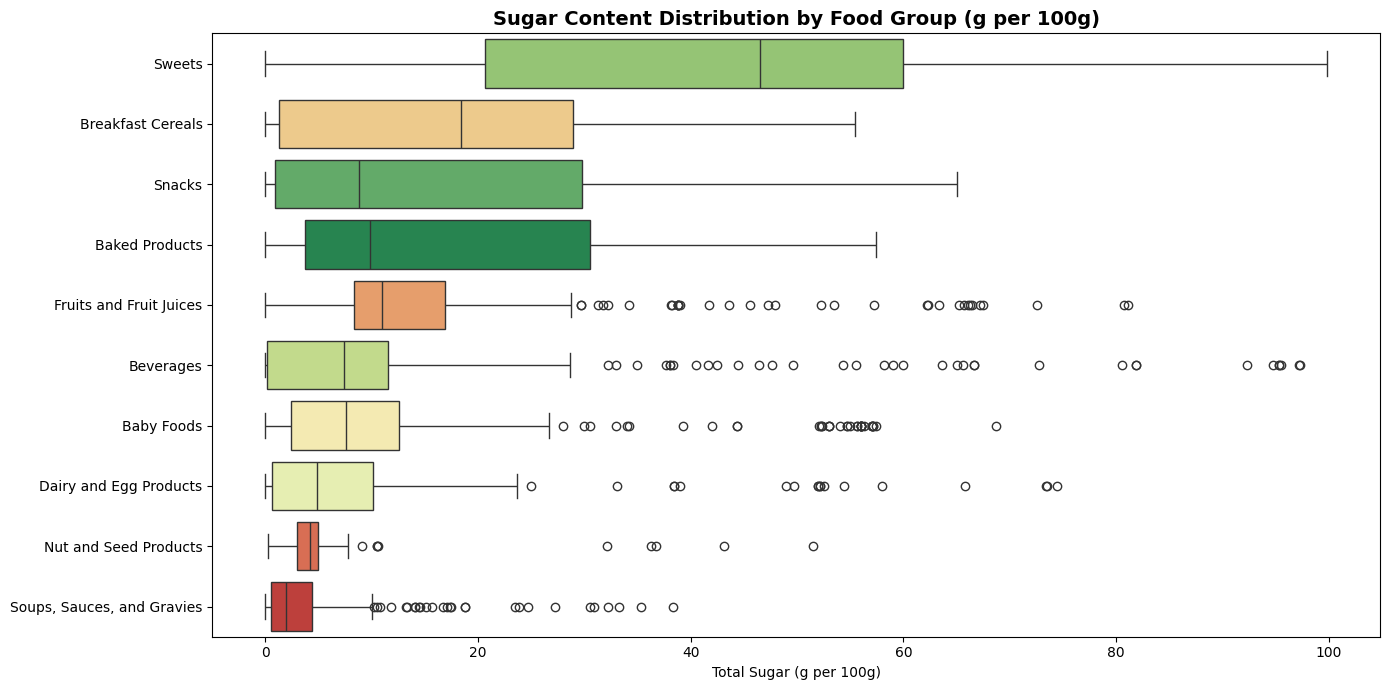

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 groups by average sugar
top_groups = sugar_by_group.head(10)['food_category'].tolist()
df_plot = df_sugar[df_sugar['food_category'].isin(top_groups)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=df_plot,
    x='Sugar_g',
    y='food_category',
    order=top_groups,
    hue='food_category',
    palette='RdYlGn_r',
    legend=False,
    ax=ax
)
ax.set_title('Sugar Content Distribution by Food Group (g per 100g)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sugar (g per 100g)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/a2_sugar_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Select nutrients that contribute positively and negatively to health
positive = ['Protein_g', 'Fiber_g', 'Calcium_mg', 'Iron_mg', 'VitaminC_mg']
negative = ['Sugar_g', 'Fat_g', 'Sodium_mg']

df_score = df.copy()

# Fill nulls with 0 for scoring
for col in positive + negative:
    if col in df_score.columns:
        df_score[col] = df_score[col].fillna(0)

# Normalise each nutrient to 0–1 scale
scaler = MinMaxScaler()
for col in positive:
    if col in df_score.columns:
        df_score[f'{col}_norm'] = scaler.fit_transform(df_score[[col]])
for col in negative:
    if col in df_score.columns:
        # Invert: lower is better, so 1 - normalised value
        df_score[f'{col}_norm'] = 1 - scaler.fit_transform(df_score[[col]])

# Composite score: sum of normalised positive + normalised negative penalty
pos_cols = [f'{c}_norm' for c in positive if c in df_score.columns]
neg_cols = [f'{c}_norm' for c in negative if c in df_score.columns]
df_score['nutrient_density_score'] = (
    df_score[pos_cols].sum(axis=1) + df_score[neg_cols].sum(axis=1)
)

# Normalise final score to 0–100
df_score['nds'] = scaler.fit_transform(df_score[['nutrient_density_score']]) * 100

# Top 25 foods
top_foods = df_score.nlargest(25, 'nds')[['description', 'food_category', 'nds']]
print(top_foods)

                                            description  \
3426                               Spices, thyme, dried   
3805                               Spices, basil, dried   
3416                            Spices, marjoram, dried   
4727                                   Spearmint, dried   
2283         Whale, beluga, meat, dried (Alaska Native)   
508   Seal, bearded (Oogruk), meat, dried (Alaska Na...   
2974                              Parsley, freeze-dried   
3424                             Spices, savory, ground   
6790                Soy protein isolate, potassium type   
5725  Beverages, Orange-flavor drink, breakfast type...   
2777                                   Corn bran, crude   
90      Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
6764                                Soy protein isolate   
3816                             Spices, oregano, dried   
1533       Gums, seed gums (includes locust bean, guar)   
1069                           Fungi, Cloud ears, dried 

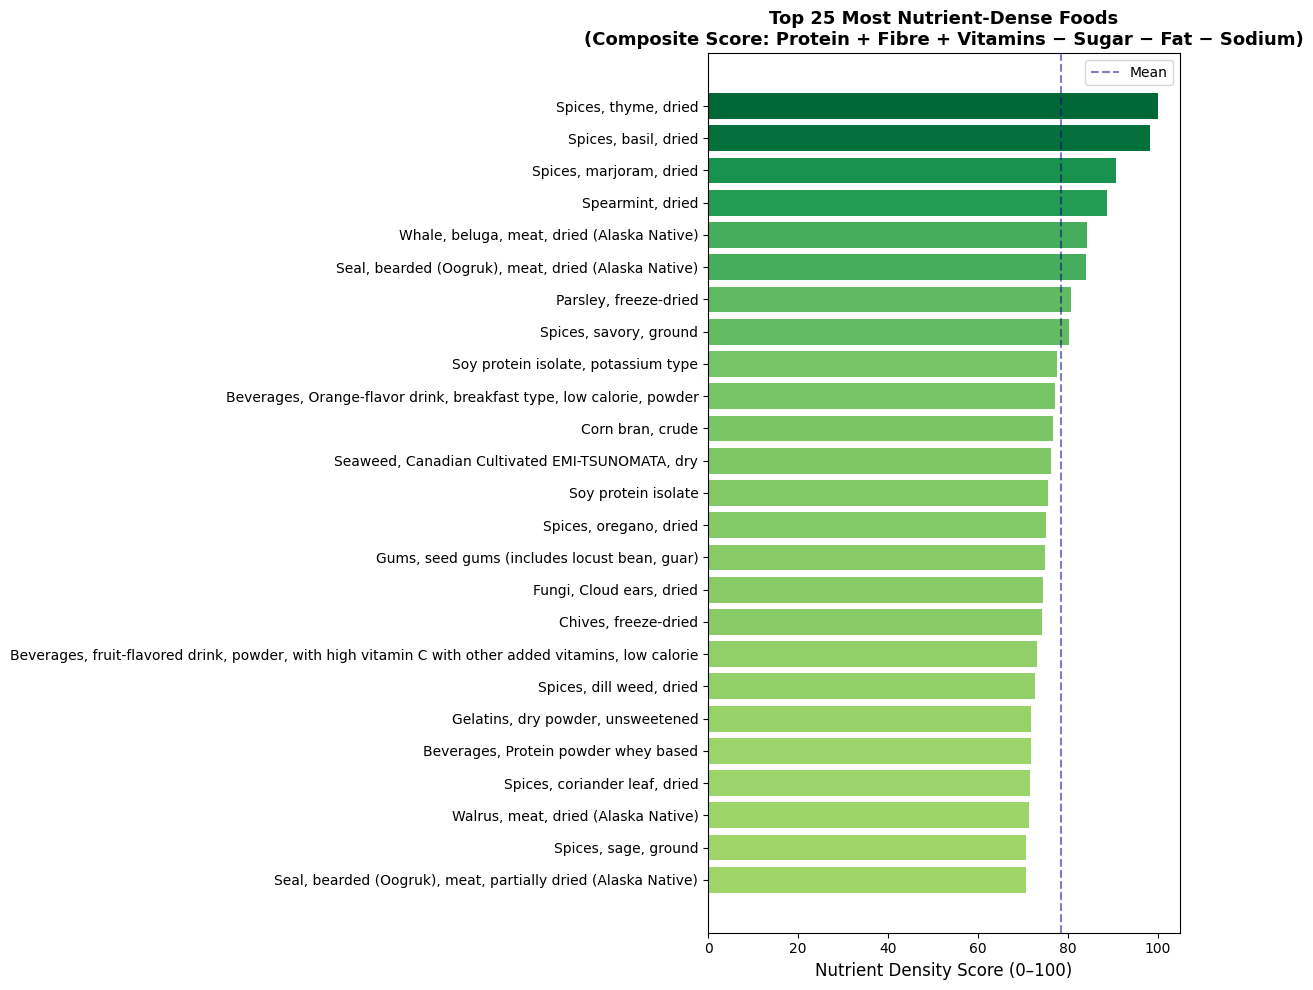

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
top25 = df_score.nlargest(25, 'nds').sort_values('nds')
colours = plt.cm.RdYlGn([x / 100 for x in top25['nds']])
bars = ax.barh(top25['description'], top25['nds'], color=colours)
ax.set_xlabel('Nutrient Density Score (0–100)', fontsize=12)
ax.set_title('Top 25 Most Nutrient-Dense Foods\n(Composite Score: Protein + Fibre + Vitamins − Sugar − Fat − Sodium)',
             fontsize=13, fontweight='bold')
ax.axvline(x=top25['nds'].mean(), color='navy', linestyle='--', alpha=0.5, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/a3_nutrient_density.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Calculate macro percentages (macros sum to ~100% of non-water calories)
df_macro = df.copy()
df_macro = df_macro[df_macro['Energy_kcal'] > 50].copy()  # exclude near-zero calorie foods

# Calories from each macro (Atwater factors)
df_macro['kcal_protein'] = df_macro['Protein_g'] * 4
df_macro['kcal_carbs']   = df_macro['Carbs_g'] * 4
df_macro['kcal_fat']     = df_macro['Fat_g'] * 9

df_macro['kcal_macro_total'] = (df_macro['kcal_protein'] +
                                 df_macro['kcal_carbs'] +
                                 df_macro['kcal_fat'])

# Avoid division by zero
df_macro = df_macro[df_macro['kcal_macro_total'] > 0]

df_macro['pct_protein'] = df_macro['kcal_protein'] / df_macro['kcal_macro_total'] * 100
df_macro['pct_carbs']   = df_macro['kcal_carbs']   / df_macro['kcal_macro_total'] * 100
df_macro['pct_fat']     = df_macro['kcal_fat']     / df_macro['kcal_macro_total'] * 100

# Average by food group
macro_by_group = (df_macro
    .groupby('food_category')[['pct_protein','pct_carbs','pct_fat']]
    .mean()
    .reset_index()
    .sort_values('pct_protein', ascending=False)
)
print(macro_by_group.head(15))

                          food_category  pct_protein  pct_carbs    pct_fat
10       Finfish and Shellfish Products    68.423832   3.892189  27.683979
17                     Poultry Products    55.258516   1.414809  43.326675
3                         Beef Products    52.166540   0.205011  47.628448
12        Lamb, Veal, and Game Products    51.684491   0.304955  48.010554
16                        Pork Products    51.524867   1.176571  47.298562
0   American Indian/Alaska Native Foods    42.421731  25.489274  32.088994
19          Sausages and Luncheon Meats    29.021673   6.767499  64.210828
7                Dairy and Egg Products    27.184617  29.031131  43.784252
13          Legumes and Legume Products    27.036353  49.788726  23.174921
8                            Fast Foods    20.608260  37.282699  42.109041
18                     Restaurant Foods    19.529829  37.353064  43.117107
14      Meals, Entrees, and Side Dishes    15.895267  53.428266  30.676466
21           Soups, Sauce

In [9]:
import plotly.graph_objects as go

top_groups = macro_by_group.head(15)

fig = go.Figure()
fig.add_trace(go.Bar(name='% Protein', x=top_groups['food_category'],
                     y=top_groups['pct_protein'], marker_color='#2196F3'))
fig.add_trace(go.Bar(name='% Carbs', x=top_groups['food_category'],
                     y=top_groups['pct_carbs'], marker_color='#FF9800'))
fig.add_trace(go.Bar(name='% Fat', x=top_groups['food_category'],
                     y=top_groups['pct_fat'], marker_color='#F44336'))

fig.update_layout(
    barmode='stack',
    title='Macro Distribution by Food Group (% of Calories)',
    xaxis_tickangle=-45,
    yaxis_title='% of Calories',
    legend_title='Macronutrient',
    height=550, width=1100
)
fig.write_html('outputs/a4_macro_distribution.html')
fig.show()

In [10]:
# Select key nutrients for correlation
key_nutrients = [
    'Energy_kcal', 'Protein_g', 'Carbs_g', 'Fat_g',
    'Sugar_g', 'Fiber_g', 'Sodium_mg', 'Calcium_mg',
    'Iron_mg', 'VitaminC_mg', 'Cholesterol_mg'
]
available = [n for n in key_nutrients if n in df.columns]
df_corr = df[available].dropna(thresh=len(available)//2)
corr_matrix = df_corr.corr()
print(corr_matrix.round(2))

                Energy_kcal  Protein_g  Carbs_g  Fat_g  Sugar_g  Fiber_g  \
Energy_kcal            1.00       0.12     0.43   0.83     0.29     0.19   
Protein_g              0.12       1.00    -0.31   0.05    -0.31    -0.09   
Carbs_g                0.43      -0.31     1.00  -0.08     0.67     0.46   
Fat_g                  0.83       0.05    -0.08   1.00    -0.03    -0.02   
Sugar_g                0.29      -0.31     0.67  -0.03     1.00     0.10   
Fiber_g                0.19      -0.09     0.46  -0.02     0.10     1.00   
Sodium_mg              0.05       0.00     0.06   0.01    -0.01    -0.00   
Calcium_mg             0.13       0.04     0.20   0.02     0.13     0.24   
Iron_mg                0.17       0.15     0.29  -0.03     0.07     0.38   
VitaminC_mg           -0.04      -0.08     0.07  -0.06     0.05     0.06   
Cholesterol_mg         0.03       0.28    -0.22   0.09    -0.16    -0.15   

                Sodium_mg  Calcium_mg  Iron_mg  VitaminC_mg  Cholesterol_mg  
Energy_kc

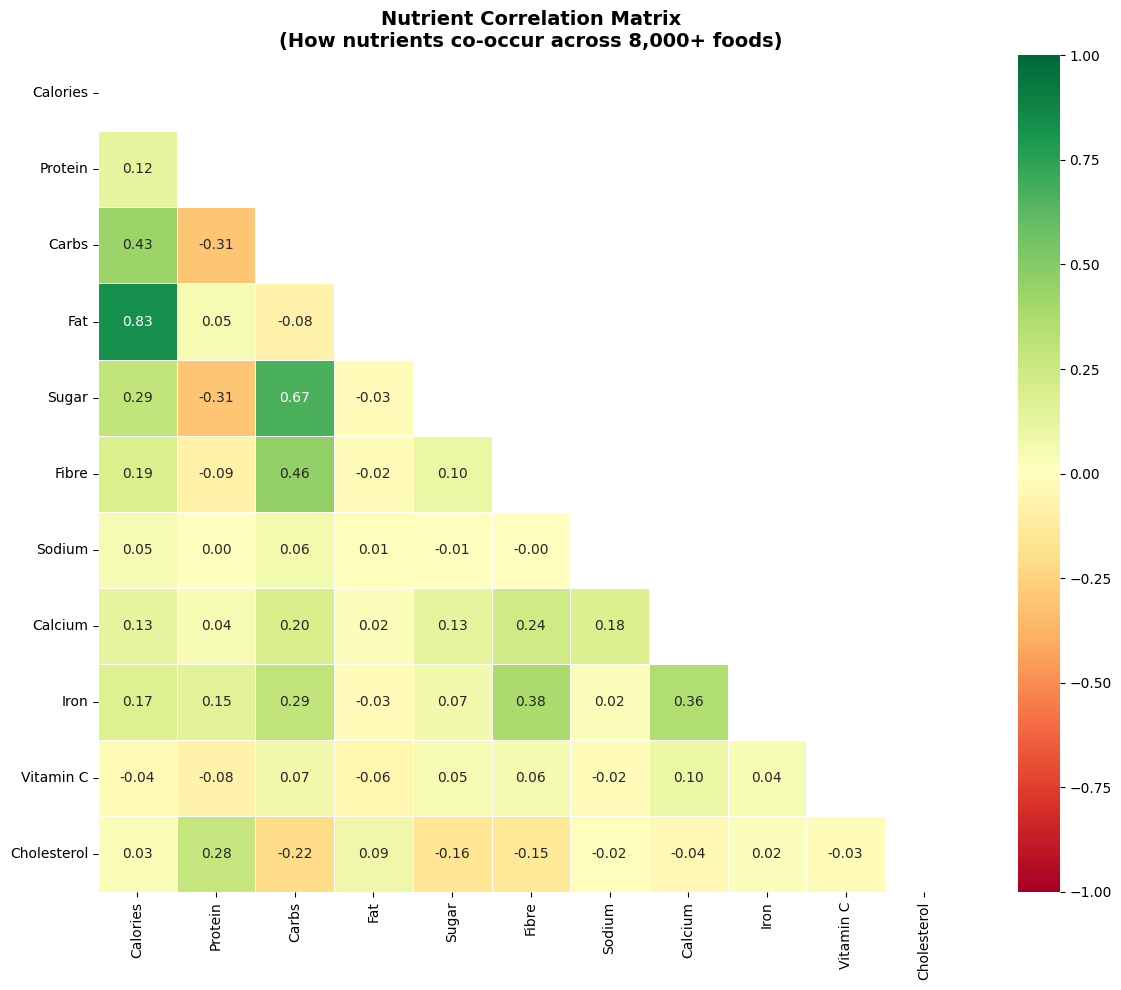

In [11]:
import numpy as np

# Shorten labels for readability
short_labels = {
    'Energy_kcal': 'Calories',
    'Protein_g': 'Protein',
    'Carbs_g': 'Carbs',
    'Fat_g': 'Fat',
    'Sugar_g': 'Sugar',
    'Fiber_g': 'Fibre',
    'Sodium_mg': 'Sodium',
    'Calcium_mg': 'Calcium',
    'Iron_mg': 'Iron',
    'VitaminC_mg': 'Vitamin C',
    'Cholesterol_mg': 'Cholesterol',
}
corr_matrix.index = [short_labels.get(i, i) for i in corr_matrix.index]
corr_matrix.columns = [short_labels.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Nutrient Correlation Matrix\n(How nutrients co-occur across 8,000+ foods)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/a5_nutrient_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()